# Train smaller or finetune larger models

In [1]:
import hierarchical_binary_quantization.hbq as hbq
import hierarchical_binary_quantization.example_autoencoder_with_rope as eae
import lpips
import matplotlib.pyplot as plt
import math, random
import os
import time
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import hierarchical_binary_quantization.misc.checkpoint_helpers as ch
from datetime import datetime
from hierarchical_binary_quantization.example_autoencoder_with_rope import ExampleQuantizingAutoencoderWithRope
from hierarchical_binary_quantization.misc.checkpoint_helpers import save_checkpoint,load_checkpoint

import hierarchical_binary_quantization.example_narrow_reciptive_field_autoencoder as enrfa

from pathlib import Path
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset
from tqdm.auto import tqdm
from datetime import timedelta

dataset='fantasy'
batch_size=4
target_size=256
training_device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

#cp_path = 'checkpoints/good/2026-08-04_02:00:00finetune_256_5_bd_96_ld_32_qd_8.pth'
#cp_path = 'checkpoints/ExampleQuantizingAutoencoderWithRope_2026-09-01_22-34-06_16x16_256_5_bd_96_ld_32_qd_16.pth'
cp_path = 'checkpoints/good/ExampleQuantizingAutoencoderWithRope_2026-09-03_06-23-04_32x32_256_4_bd_96_ld_32_qd_16.pth'

#cp_path = None
if False:
    cfgdict = ch.check_checkpoint(cp_path)['config']
    cfg = eae.HBQAutoencoderConfig(**cfgdict)
    print(cfg)
else:
    cfg = eae.HBQAutoencoderConfig(
        in_channels=3, 
        base_dim=96, 
        channel_multipliers=(1, 2, 3, 4), 
        res_blocks=(1, 2, 3, 3), 
        latent_dim=32, quant_dim=8, n_rounds=4
    )

cfg_32x32 = eae.HBQAutoencoderConfig(
    in_channels=3,
    base_dim=96,
    channel_multipliers=(1, 2, 3, 4),
    res_blocks=(1, 2, 3, 3),
    latent_dim=32,
    quant_dim=16,
    n_rounds=4,
    bottleneck_heads=8,
    bottleneck_layers=2,
    use_mae_aux=True,
    mae_mask_ratio=0.5,
    mae_heads=4,
    mae_depth=2,
    protected_channel_fraction=0.5,
)

cfg_16x16 = eae.HBQAutoencoderConfig(
    in_channels=3,
    base_dim=96,
    channel_multipliers=(1, 2, 3, 4, 4),
    res_blocks=(1, 2, 3, 3, 3),
    latent_dim=32,
    quant_dim=16,
    n_rounds=4,
    bottleneck_heads=8,
    bottleneck_layers=2,
    use_mae_aux=True,
    mae_mask_ratio=0.5,
    mae_heads=4,
    mae_depth=2,
    protected_channel_fraction=0.5,
)
cfg = cfg_32x32


cp_path = None
if cp_path:
    cfgdict = ch.check_checkpoint(cp_path)['config']
    cfg = eae.LocalAutoencoderConfig(**cfgdict)
    print(cfg)
else:
    """
    class LocalAutoencoderConfig:
    in_channels: int = 3
    stem_dim: int = 64
    stem_blocks: int = 2
    patch_size: int = 16
    body_dim: int = 256
    body: tuple = ("res", "attn", "res", "attn", "res", "attn", "res", "attn")
    attn_block: int = 4        # neighborhood-attention query block size, in TOKENS
    attn_halo: int = 1         # neighborhood-attention halo, in TOKENS
    attn_heads: int = 4
    latent_dim: int = 32
    quant_dim: int = 8
    n_rounds: int = 4
    refine_blocks: int = 2     # post-de-patchify local cleanup at full resolution
    use_mae_aux: bool = True
    mae_mask_ratio: float = 0.5
    mae_heads: int = 2
    mae_depth: int = 2
    """
    cfg = enrfa.LocalAutoencoderConfig( patch_size=8, body_dim=256, quant_dim=8, n_rounds=4)
cfg

def get_autoencoder(cfg):
    if isinstance(cfg,enrfa.LocalAutoencoderConfig):
        autoencoder = enrfa.LocalQuantizingAutoencoder(cfg)
    else:
        autoencoder = eae.ExampleQuantizingAutoencoderWithRope(cfg)
    return autoencoder


/home/ron/proj/hierarchical-binary-quantization/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# if resume_from_legacy_checkpoint_format := False:
#     path = 'checkpoints/legacy_finetune_256_5_bd_96_ld_32_qd_8.pth'
#     old_cp = torch.load(path,map_location='cpu')
#     autoencoder = eae.load_legacy_quant_checkpoint(autoencoder, old_cp['model_state_dict'])
#     autoencoder.eval()

def show_shapes():
    autoencoder = get_autoencoder(cfg)
        
    if cp_path:
        ch.load_checkpoint(autoencoder,None,cp_path)
    pass
    #autoencoder.to('cuda')
    #with torch.amp.autocast(device_type='cuda', dtype=torch.float16):

    imgs = torch.rand(batch_size,3,target_size,target_size)
    reconstructions, aux = autoencoder.forward(imgs)
    print(f"""
        input: {imgs.shape}
        latents: {aux.latents.shape}
        quantized: {aux.quant_info.quantized.shape}
        bit_codes: {aux.quant_info.bit_codes.shape}
        tokens: {aux.quant_info.tokens is not None and aux.quant_info.tokens.shape}
        reconstructions: {reconstructions.shape}
        """)

show_shapes()
    


        input: torch.Size([4, 3, 256, 256])
        latents: torch.Size([4, 32, 32, 32])
        quantized: torch.Size([4, 8, 32, 32])
        bit_codes: torch.Size([4, 8, 32, 32])
        tokens: torch.Size([4, 32, 32])
        reconstructions: torch.Size([4, 3, 256, 256])
        


## Dataset config

In [3]:
class ImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
        self.files = []
        for ext in exts:
            self.files.extend(Path(root).rglob(ext))
        self.files = sorted(self.files)
        print(f"Found {len(self.files)} images.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize(target_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dataset = ImageDataset(
    root=f"./data/256x256/{dataset}",
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

print(f"{len(train_dataset)} training images")
next(iter(train_loader)).shape

Found 12814 images.
12814 training images


torch.Size([4, 3, 256, 256])

In [4]:

import matplotlib.pyplot as plt
import torch
from PIL import Image
import numpy as np
import hierarchical_binary_quantization.misc.image_helpers as ih
import IPython.display as ipd

def show_reconstructions(model, imgs):
    was_training = model.training
    model.eval()
    with torch.inference_mode():
        reconstructions, aux = model(imgs[:1])
    if was_training:
        model.train()
    original = ih.tensor_to_pil(imgs[0])
    reconstruction = ih.tensor_to_pil(reconstructions[0])
    latent = ih.tensor_to_pil(ih.q_out_to_rgb(aux.quant_info.quantized)[0])
    if aux.quant_info.tokens is not None:
        unique = aux.quant_info.tokens.unique().numel()
        print(
            f"unique tokens={unique} out of "
            f"{2**(aux.quant_info.n_rounds * model.config.quant_dim)}."
        )

    with torch.inference_mode():
        # real quantized codes everywhere except the masked spots, where we
        # substitute the predictor's guess -- so a bad fill only ever shows up
        # as a bad fill, not compounded with untrained noise everywhere else.
        composite = aux.mae_mask * aux.mae_pred + (1 - aux.mae_mask) * aux.quant_info.quantized
        mae_lat = autoencoder.post_quant(composite)
        # mae_out = autoencoder.backbone.decode(mae_lat)  # The global attention one
        mae_out = autoencoder.decode(mae_lat)

        #mae_out = (mae_out / 2 + 0.5).clamp(0, 1)
        mae_img = ih.tensor_to_pil(mae_out.cpu()[0])
    h = ih.html_for_images([original, latent, reconstruction, mae_img],min_height=256)    
    return h, original, latent, reconstruction

# imgs = next(iter(train_loader)).to('cpu')
# h,*i2 = show_reconstructions(autoencoder, imgs)
# ipd.display(ipd.HTML(h))


## Train The Model

In [5]:
### Prep for training

autoencoder = get_autoencoder(cfg)
if resume:=cp_path:
    good_checkpoint = cp_path
    #cfg = ch.check_checkpoint(good_checkpoint)['config']
    #autoencoder = eae.ExampleQuantizingAutoencoderWithRope(**cfg)
    ch.load_checkpoint(autoencoder,None,good_checkpoint,strict=False)




In [6]:
quantizer = hbq.QuantizerRandomizer([
    hbq.HBQQuantizer(n_rounds=1),
    hbq.HBQQuantizer(n_rounds=2),
    hbq.HBQQuantizer(n_rounds=3),
    hbq.HBQQuantizer(n_rounds=4),
])

autoencoder.quantizer = quantizer

# quant_dim=8, n_rounds = 4 = 32 bits

autoencoder.to(training_device)
optimizer = torch.optim.AdamW(
    autoencoder.parameters(),
    lr=1e-4, # 3e-4 often fails to converge on Cats&Dogs dataset (mostly brown; local minima of all brown images can be found with huge weights)
    weight_decay=1e-4,
)

if cp_path:
    ch.load_checkpoint(autoencoder, optimizer, cp_path, strict=True)

print(autoencoder.config)
print(
    f"Parameters: {sum(p.numel() for p in autoencoder.parameters())/1e6:.2f}M"
)


LocalAutoencoderConfig(in_channels=3, stem_dim=64, stem_blocks=2, patch_size=8, body_dim=256, body=('res', 'attn', 'res', 'attn', 'res', 'attn', 'res', 'attn'), attn_block=4, attn_halo=1, attn_heads=4, latent_dim=32, quant_dim=8, n_rounds=4, refine_blocks=2, use_mae_aux=True, mae_mask_ratio=0.5, mae_heads=2, mae_depth=2)
Parameters: 13.97M


In [7]:
import torch.nn.functional as F
def color_difference_loss(pred, target):
    return (
        F.l1_loss(pred[:,0]-pred[:,1], target[:,0]-target[:,1]) +
        F.l1_loss(pred[:,0]-pred[:,2], target[:,0]-target[:,2]) +
        F.l1_loss(pred[:,1]-pred[:,2], target[:,1]-target[:,2])
    )


In [8]:
import mlflow
from mlflow.tracking import MlflowClient

# uv run mlflow ui --backend-store-uri sqlite:///mlflow.db
class MLFlowHelper:

    def __init__(self, experiment_name, run_name=None, loggable_params={"reminder":"log your parameters"}):

        self.experiment_name = experiment_name
        self.run_name = run_name
        self.loggable_params = loggable_params
        self.logged_step = 0
        mlflow.set_tracking_uri("sqlite:///mlflow.db")
        mlflow.set_experiment(self.experiment_name)

        if run_name is None:
            with mlflow.start_run() as run:
                self.run_name = run.info.run_name
                self.run_id = run.info.run_id

        self.run_id = self.get_mflow_run_id()
        if not self.run_id:
            with mlflow.start_run(run_name=self.run_name):
                pass
            self.run_id = self.get_mflow_run_id()

        with mlflow.start_run(run_id=self.run_id):
            for k,v in loggable_params.items():
                mlflow.log_param(k,v)  

    def get_mflow_run_id(self):
        runs = mlflow.search_runs(
            experiment_names=[self.experiment_name],
            filter_string=f"attributes.run_name = '{self.run_name}'"
        )

        if not runs.empty:
            mlflow_run_id = runs.iloc[0]["run_id"]
            print(f"Found existing run: {mlflow_run_id}. Resuming...")
            return mlflow_run_id
        else:
            print(f"No existing run found with run_name {self.run_name}.")
            return None

    def log_to_mlflow(self, mlflow_step, metrics):
        with mlflow.start_run(run_id=self.run_id):
            for k,v in metrics.items():
                mlflow.log_metric(k, v, step=mlflow_step)


# for i in range(3):
#     mfh.log_to_mlflow(i, {"elapsed_seconds":1,"samples_per_second":1,"loss":1})
# mlflow.end_run()

In [9]:

import torch
import time
from tqdm import tqdm
import torch.nn.functional as F

def train_some(autoencoder, optimizer, train_loader, device, 
               continued_training_elapsed_time=0,
               continued_training_item_counter=0,
               epochs=1_000_000,grad_checkpointing=False,
               max_training_time = 60 * 60 * 24 * 7,
               exp_name="hbq", run_name=None
              ):

    mfh = MLFlowHelper(exp_name,run_name)
    ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    output_file = f"outputs/{exp_name}_{run_name}_{ts}.html"

    with open(output_file,"a") as f:
        f.write(f"<pre>{str(autoencoder.config)}</pre><br>")
    autoencoder.to(device)
    #autoencoder.set_grad_checkpointing(grad_checkpointing)

    loss_history = []
    t0 = time.time()
    item_counter = 0
    display_interval = 1
    next_display = t0 + display_interval
    loss_fn = lpips.LPIPS(net='vgg').eval().requires_grad_(False).to(device)    
    
    scaler = torch.amp.GradScaler('cuda')
    
    for epoch in range(epochs):
        if time.time() - t0 > max_training_time:
            break
        autoencoder.train()
        running_loss = 0.0
        progress = tqdm(train_loader)
        for imgs in progress:
            if time.time() - t0 > max_training_time:
                break

            imgs = imgs.to(device)
            optimizer.zero_grad()
            batch_size = imgs.shape[0]
            item_counter += batch_size
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                recon, aux = autoencoder(imgs)
                loss_lpips = loss_fn(recon, imgs).sum()
                loss_l1 = F.l1_loss(recon, imgs)
                loss_color = color_difference_loss(recon, imgs)
                loss_mae = aux.mae_loss()
                loss = (loss_l1 + 2.0 * loss_lpips + 0.5 * loss_color + loss_mae * 0.25)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        
            running_loss += loss.item()
            progress.set_description(f"Epoch {epoch+1}/{epochs} {loss.item():.3f}")
            
            if time.time() > next_display:
                total_training_time = time.time() - t0 + continued_training_elapsed_time
                next_display = time.time() + display_interval
                display_interval = min(1.2*display_interval, 60*30)

                loggable_params = {
                    "loss":loss.item(),
                    "loss_l1":loss_l1.item(),
                    "loss_lpips":loss_lpips.item(),
                    "loss_color": loss_color.item(),
                    "loss_mae": loss_mae.item(),
                    "items":continued_training_item_counter + item_counter,
                    "latent_μ":aux.latents.mean().item(),
                    "latent_σ": aux.latents.std().item(),
                }
                mfh.log_to_mlflow(total_training_time//60, loggable_params)
                def nicev(v):
                    return f"{v:.3f}" if isinstance(v,float) else f"{v}"
                info =(
                    f"time={str(timedelta(seconds=total_training_time))} " +
                    " ".join([f"{k}:{nicev(v)} " for k,v in loggable_params.items()])
                )

                h, *imgs_show = show_reconstructions(autoencoder, imgs)
                #debug_latent_correlations(aux.latents)
                with open(output_file,"a") as f:
                    f.write(info)
                    f.write(h)
                ipd.clear_output(wait=True)
                print(info)
                ipd.display(ipd.HTML(h))
    
        epoch_loss = running_loss / len(train_loader)
        loss_history.append(epoch_loss)
        print(f"Epoch {epoch+1:2d}: {epoch_loss:.6f}")

time=0:16:31.477527 loss:1.969  loss_l1:0.176  loss_lpips:0.811  loss_color:0.093  loss_mae:0.500  items:9292  latent_μ:0.080  latent_σ:6.285 



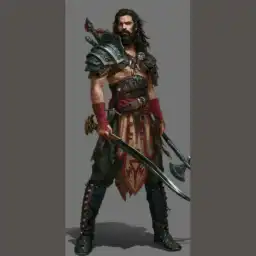
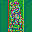
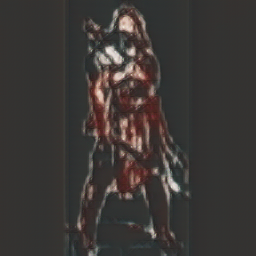
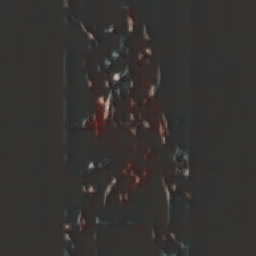

Epoch 1/1000000 2.651:  86%|████████▋ | 2766/3204 [19:34<03:04,  2.37it/s]

In [ ]:
try:
    autoencoder.mae.mask_ratio = 0.5
    train_some(autoencoder, optimizer, train_loader,device=training_device,max_training_time=8*60*60)
except KeyboardInterrupt as e:
    autoencoder.zero_grad(set_to_none=True)
    print("Done")


In [ ]:
# quantizer = hbq.QuantizerRandomizer([
#     hbq.HBQQuantizer(n_rounds=1),
#     hbq.HBQQuantizer(n_rounds=2),
#     hbq.HBQQuantizer(n_rounds=3),
#     hbq.HBQQuantizer(n_rounds=4),
# ])

# autoencoder.quantizer = quantizer

# # quant_dim=8, n_rounds = 4 = 32 bits

# autoencoder.to(training_device)
# optimizer = torch.optim.AdamW(
#     autoencoder.parameters(),
#     lr=1e-4, # 3e-4 often fails to converge on Cats&Dogs dataset (mostly brown; local minima of all brown images can be found with huge weights)
#     weight_decay=1e-4,
# )

# try:
#     autoencoder.mae.mask_ratio = 0.5
#     train_some(autoencoder, optimizer, train_loader,device=training_device,max_training_time=7*60*60)
# except KeyboardInterrupt as e:
#     autoencoder.zero_grad(set_to_none=True)
#     print("Done")


In [ ]:
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
cls_name = autoencoder.__class__.__name__
tag = f"tmp_work_in_progress"
path = f"checkpoints/{cls_name}_{timestamp}_{tag}.pth"
    
save_checkpoint(autoencoder,path,optimizer=optimizer)

In [ ]:
!ls -lrt checkpoints

In [ ]:
!cp 'checkpoints/ExampleQuantizingAutoencoderWithRope_2026-09-03_06-23-04_32x32_256_4_bd_96_ld_32_qd_16.pth' checkpoints/good/

In [ ]:
def debug_latent_correlations(latent):
    with torch.no_grad():
        z = latent  # (B,C,H,W), BEFORE tanh
        # One row per channel, one column per sample/pixel
        x = z.permute(1, 0, 2, 3).reshape(z.shape[1], -1)
        # Center each channel
        x = x - x.mean(dim=1, keepdim=True)
        # Normalize each channel to unit variance
        x = x / (x.std(dim=1, keepdim=True) + 1e-8)
        # Correlation matrix
        corr = (x @ x.T) / x.shape[1]
        print("Channel correlation:")
        print(corr.cpu().numpy().round(2))
        offdiag = corr - torch.eye(corr.shape[0], device=corr.device)
        mean_abs_corr = offdiag.abs().sum() / (corr.numel() - corr.shape[0])
        print(f"Mean |off-diagonal correlation| = {mean_abs_corr:.3f}")
with torch.no_grad():
    autoencoder.to('cpu')
    i,aux = autoencoder(next(iter(train_loader)).to('cpu'))
# A suggestion from ChatGPT to debug if color was bottlenecked before the quantizer.
print(aux.latents.shape, aux.quant_info.quantized.shape, aux.quant_info.tokens is not None and aux.quant_info.tokens.shape)
debug_latent_correlations(autoencoder.pre_quant(aux.latents))

In [ ]:
# !cp checkpoints/ExampleQuantizingAutoencoder_2026-08-04_23-40-17_finetune_256_4_bd_96_ld_32_qd_8.pth checkpoints/good/2026-08-04_23-41-00_256_4_bd_96_ld_32_qd_8.pth
# !ls -l checkpoints/good


In [ ]:
!pwd
!ls -lrth checkpoints

In [ ]:
# import importlib
# import hierarchical_binary_quantization.example_autoencoder_with_rope as eae
# import hierarchical_binary_quantization
# import hierarchical_binary_quantization.misc.checkpoint_helpers as ch
# importlib.reload(eae)
# importlib.reload(hierarchical_binary_quantization)
# good_checkpoint = cp_path 
# cfg = ch.check_checkpoint(good_checkpoint)['config']
# autoencoder = eae.ExampleQuantizingAutoencoderWithRope(**cfg)
# ch.load_checkpoint(autoencoder,None,good_checkpoint)


In [ ]:
import torch
with torch.no_grad():
    autoencoder.cpu()
    autoencoder.quantizer = hbq.HBQQuantizer(n_rounds=1)
    i,aux = autoencoder(next(iter(train_loader)))

aux.quant_info.tokens.cpu()[0]
histogram = torch.bincount(aux.quant_info.tokens.cpu()[0].flatten())
histogram

In [ ]:
imgs = next(iter(train_loader))
autoencoder.mae.mask_ratio=0.5
autoencoder.quantizer = hbq.HBQQuantizer(n_rounds=4)
h,*i2 = show_reconstructions(autoencoder, imgs.to('cpu'))
ipd.HTML(h)

In [ ]:
from hierarchical_binary_quantization.hbq import (
    bit_codes_to_tokens, tokens_to_bit_codes, bit_codes_to_quantized_latent,
)
@torch.inference_mode()
def decode_all_levels(autoencoder, imgs, max_rounds=4):
    """bit_codes: (B, L, H, W) int, full-resolution accumulated codes.
    Returns {round: images (B, C, H, W) in [0,1]} for round in 1..max_rounds."""
    with torch.inference_mode():
        reconstructions, aux = autoencoder(imgs[:1])

    latents = aux.latents
    bit_codes = aux.quant_info.bit_codes
    original = imgs[0].detach().cpu().permute(1,2,0)
    results = {}
    results['orig'] = original
    for r in range(1, max_rounds + 1):
        r_bits = bit_codes >> (max_rounds - r)                    # (B, L, H, W)
        r_bits = r_bits.permute(0, 2, 3, 1)                        # (B, H, W, L)
        quantized = bit_codes_to_quantized_latent(r_bits, n_rounds=r)
        quantized = quantized.permute(0, 3, 1, 2).contiguous()     # (B, L, H, W)
        z = autoencoder.post_quant(quantized)
        images = autoencoder.backbone.decode(z)
        #images = (images / 2 + 0.5).clamp(0, 1)
        results[r] = images.cpu()

        z2 = autoencoder.post_quant(aux.mae_pred)
        images2 = autoencoder.backbone.decode(z2)
        images2 = (images2 / 2 + 0.5).clamp(0, 1)
        results[f"mae{r}"] = images2.cpu()

        
    if True:
        inf = autoencoder.backbone.decode(autoencoder.post_quant(autoencoder.pre_quant(latents)))
        #inf = (inf / 2 + 0.5).clamp(0, 1)
        results['inf'] = inf.cpu()
    return results
autoencoder.quantizer = hbq.HBQQuantizer(n_rounds=4)
autoencoder.mae.mask_ratio = 0.51
levels = decode_all_levels(autoencoder,imgs)
print(levels.keys())
all_imgs = [
    levels['orig'], levels[1][0], levels[2][0], levels[3][0], levels[4][0], levels['inf'][0],
    levels["mae1"][0],levels["mae4"][0],
    ]
titles = ["original","round1", "round2", "round3", "round4", "round infinity"]
zimgs = [ih.tensor_to_pil(i) for i in all_imgs]
ipd.display(ipd.HTML(ih.html_for_images(zimgs, title=" / ".join(titles), min_height=128)))

In [ ]:
autoencoder.mae.mask_ratio = 0.4
h, *imgs_show = show_reconstructions(autoencoder, imgs)
#debug_latent_correlations(aux.latents)
ipd.display(ipd.HTML(h))

In [ ]:
autoencoder.mae.mask_ratio = 0.3
h, *imgs_show = show_reconstructions(autoencoder, imgs)
#debug_latent_correlations(aux.latents)
ipd.display(ipd.HTML(h))

In [ ]:
autoencoder.mae.mask_ratio = 0.1
h, *imgs_show = show_reconstructions(autoencoder, imgs)
#debug_latent_correlations(aux.latents)
ipd.display(ipd.HTML(h))

In [ ]:
autoencoder.mae.mask_ratio = 0.1
h, *imgs_show = show_reconstructions(autoencoder, imgs)
#debug_latent_correlations(aux.latents)
ipd.display(ipd.HTML(h))